<a href="https://colab.research.google.com/github/kittiporntum1-cell/ADALL_github/blob/main/Tum3_Copy_of_ADALL_Practical_Test_Revision_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ADALL Practical Test Revision: Regression Workflow

## Single-session version

This notebook is designed for **one revision session**.

The main route is short. Read the optional sections only after you finish the main route.

### Session target
By the end of this session, you should be able to:

1. explain why this is a **regression** task,
2. create the target `num_failed_subjects`,
3. avoid leakage from `G1`, `G2`, and `G3`,
4. create a dataset profile for LLM review,
5. train models using a pipeline,
6. compare results using CV and holdout MAE,
7. write a short judgement-based answer.

### Suggested timing

| Part | Time |
|---|---:|
| Admin and test reminder | 10 to 15 min |
| Main route in this notebook | 75 to 90 min |
| Recap and Q&A | 15 to 20 min |
| Optional practice | After class |

<div style="background-color:#eaf4ff; border-left:6px solid #2b7bbb; padding:12px;">
<strong>Main idea:</strong> The practical test is not mainly about writing many new lines of code. It is about knowing what the code is doing, running the right block, checking the result, and explaining your decision clearly.
</div>


## What the previous lecturer focused on

The transcript suggests that this revision should focus on the following points:

| Focus area | What students should pay attention to |
|---|---|
| Regression only | The practical test focuses on predicting a number, not classification. |
| Read instructions carefully | If a cell says “run only”, do not edit it unnecessarily. |
| Dataset profile and payload text | You should know how to summarise the dataset for LLM-assisted review. |
| Leakage | `G1`, `G2`, and `G3` directly define the target, so they must not be used as predictors. |
| Train/test split | Keep the test set for final checking. Use a fixed `random_state`. |
| Pipeline | Use the same preprocessing and modelling structure fairly. |
| Model comparison | Choose based on evidence, not because a model sounds more advanced. |

<div style="background-color:#fff8e6; border-left:6px solid #d69b00; padding:12px;">
<strong>Revision stance:</strong> You are practising judgement. Do not accept every LLM recommendation automatically. Check whether the recommendation makes sense for the task.
</div>


| Problem Type   | Example                        | Model               |
| -------------- | ------------------------------ | ------------------- |
| Regression     | Predict house price = $500,000 | Linear Regression   |
| Classification | Predict Pass / Fail            | Logistic Regression |



**Note: Logistic Regression**

 0 / 1
Yes / No
Pass / Fail
Churn / Stay
Fraud / Not Fraud


| Model               | Type                        |
| ------------------- | --------------------------- |
| Logistic Regression | Linear Classification Model |
| Decision Tree       | Tree-Based Model            |
| Random Forest       | Ensemble Tree Model         |
| XGBoost             | Boosted Tree Model          |


| Model               | Classification Version     |
| ------------------- | -------------------------- |
| Logistic Regression | `LogisticRegression()`     |
| Decision Tree       | `DecisionTreeClassifier()` |
| Random Forest       | `RandomForestClassifier()` |
| XGBoost             | `XGBClassifier()`          |


| Model             | Regression Version        |
| ----------------- | ------------------------- |
| Linear Regression | `LinearRegression()`      |
| Decision Tree     | `DecisionTreeRegressor()` |
| Random Forest     | `RandomForestRegressor()` |
| XGBoost           | `XGBRegressor()`          |
| Ridge             | `Ridge()`                 |
| Lasso             | `Lasso()`                 |


| Target Type | Example                                          | Models                                                                                 |
| ----------- | ------------------------------------------------ | -------------------------------------------------------------------------------------- |
| Numeric     | Price, Revenue, Total Score, Num Failed Subjects | Linear Regression, Decision Tree Regressor, Random Forest Regressor, XGBRegressor      |
| Binary      | Pass/Fail, Yes/No, Churn/Stay                    | Logistic Regression, Decision Tree Classifier, Random Forest Classifier, XGBClassifier |
| Multi-Class | Grade A/B/C/D, Product Category                  | Logistic Regression, Decision Tree Classifier, Random Forest Classifier, XGBClassifier |


| Business Scenario                     | Target Variable (y)       | Predictors / Features (X)                              | Prediction Type | Potential Leakage Columns         | Recommended Models                                         |
| ------------------------------------- | ------------------------- | ------------------------------------------------------ | --------------- | --------------------------------- | ---------------------------------------------------------- |
| House Price Prediction                | House Price               | Area, Bedrooms, Bathrooms, Location, House Age         | Regression      | Selling Price, Appraisal Value    | DecisionTreeRegressor, RandomForestRegressor, XGBRegressor |
| Car Price Prediction                  | Car Price                 | Mileage, Brand, Model, Year, Fuel Type                 | Regression      | Final Sale Price                  | RandomForestRegressor, XGBRegressor                        |
| Employee Salary Prediction            | Salary                    | Experience, Education, Job Role, Department            | Regression      | Final Compensation, Bonus Amount  | RandomForestRegressor, XGBRegressor                        |
| Student Final Score Prediction        | Final Score (G3)          | Study Time, Absences, Parent Education, Activities     | Regression      | G3, Post-Exam Results             | DecisionTreeRegressor, RandomForestRegressor, XGBRegressor |
| Number of Failed Subjects Prediction  | Number of Failed Subjects | Age, Study Time, Absences, Failures, Family Support    | Regression      | G1, G2, G3                        | DecisionTreeRegressor, RandomForestRegressor, XGBRegressor |
| GPA Prediction                        | GPA                       | Attendance, Assignments, Study Hours                   | Regression      | Final GPA Components              | RandomForestRegressor, XGBRegressor                        |
| Sales Forecasting                     | Monthly Sales Revenue     | Promotion, Store Size, Product Category, Season        | Regression      | Future Sales Information          | RandomForestRegressor, XGBRegressor                        |
| Demand Forecasting                    | Units Sold                | Product Type, Price, Promotion, Season                 | Regression      | Future Demand Data                | RandomForestRegressor, XGBRegressor                        |
| Inventory Forecasting                 | Inventory Quantity        | Sales History, Product Type, Season                    | Regression      | Future Stock Levels               | RandomForestRegressor, XGBRegressor                        |
| Delivery Time Prediction              | Delivery Days             | Distance, Traffic, Weather, Vehicle Type               | Regression      | Actual Delivery Duration          | RandomForestRegressor, XGBRegressor                        |
| Shipping Cost Prediction              | Shipping Cost             | Weight, Distance, Delivery Type                        | Regression      | Final Shipping Charge             | RandomForestRegressor                                      |
| Loan Amount Prediction                | Loan Amount               | Income, Employment, Credit Score                       | Regression      | Approved Loan Amount              | XGBRegressor                                               |
| Insurance Premium Prediction          | Premium Amount            | Age, Vehicle Type, Claim History                       | Regression      | Final Premium Calculation         | XGBRegressor                                               |
| Customer Lifetime Value Prediction    | CLV                       | Purchase Frequency, Spending History, Customer Segment | Regression      | Future Revenue Data               | RandomForestRegressor, XGBRegressor                        |
| Credit Card Spending Prediction       | Monthly Spending          | Income, Age, Occupation, Card Type                     | Regression      | Future Transactions               | RandomForestRegressor                                      |
| Medical Cost Prediction               | Medical Cost              | Age, Diagnosis, Treatment Type                         | Regression      | Final Hospital Bill               | RandomForestRegressor, XGBRegressor                        |
| Hospital Length of Stay Prediction    | Days Stayed               | Diagnosis, Age, Medical History                        | Regression      | Discharge Information             | RandomForestRegressor                                      |
| Manufacturing Output Prediction       | Units Produced            | Machine Hours, Workforce, Materials                    | Regression      | Final Production Count            | RandomForestRegressor                                      |
| Defect Count Prediction               | Number of Defects         | Machine Settings, Material Quality, Temperature        | Regression      | Inspection Results                | XGBRegressor                                               |
| Marketing Campaign Revenue Prediction | Campaign Revenue          | Marketing Spend, Channel, Audience Size                | Regression      | Future Sales Generated            | XGBRegressor                                               |
| Bonus Prediction                      | Bonus Amount              | Performance Rating, Experience, Job Grade              | Regression      | Actual Bonus Payment              | RandomForestRegressor                                      |
| Overtime Hours Prediction             | Overtime Hours            | Team Size, Workload, Department                        | Regression      | Payroll Records                   | RandomForestRegressor                                      |
| Electricity Consumption Prediction    | Energy Consumption        | Season, Household Size, Appliance Usage                | Regression      | Future Meter Readings             | XGBRegressor                                               |
| Pass/Fail Prediction                  | Pass/Fail                 | Study Time, Attendance, Assignments                    | Classification  | Final Grade Used to Create Target | LogisticRegression, RandomForestClassifier, XGBClassifier  |
| Customer Churn Prediction             | Churn / Not Churn         | Usage, Tenure, Customer Complaints                     | Classification  | Account Closure Date              | LogisticRegression, RandomForestClassifier, XGBClassifier  |
| Fraud Detection                       | Fraud / Not Fraud         | Transaction Amount, Device, Location                   | Classification  | Investigation Outcome             | RandomForestClassifier, XGBClassifier                      |
| Loan Approval Prediction              | Approved / Rejected       | Income, Employment, Credit History                     | Classification  | Final Approval Status             | XGBClassifier                                              |
| Credit Default Prediction             | Default / No Default      | Income, Debt Ratio, Credit Score                       | Classification  | Future Payment Status             | XGBClassifier                                              |
| Disease Diagnosis                     | Disease / No Disease      | Age, Symptoms, Medical History                         | Classification  | Diagnostic Outcome                | RandomForestClassifier, XGBClassifier                      |
| Employee Attrition Prediction         | Leave / Stay              | Salary, Satisfaction, Years of Service                 | Classification  | Resignation Date                  | RandomForestClassifier, XGBClassifier                      |
| Product Return Prediction             | Return / No Return        | Product Category, Price, Customer Type                 | Classification  | Actual Return Status              | RandomForestClassifier                                     |
| Subscription Renewal Prediction       | Renew / Not Renew         | Plan Type, Usage History, Tenure                       | Classification  | Future Renewal Status             | XGBClassifier                                              |
| Email Spam Detection                  | Spam / Not Spam           | Email Content Features                                 | Classification  | Manual Spam Label                 | LogisticRegression, XGBClassifier                          |


# ADALL Practical Test Flow (Regression)

## Phase 1: Understand the Data

1. Load Data
2. Explore Dataset
3. Data Profiling
4. Create OpenAI Dataset Profile Payload
5. OpenAI Dataset Review
6. Data Cleaning

---

## Phase 2: Target Variable

7. Create Target Variable (if required)

Examples:
- Count
- Sum
- Average
- Min
- Max
- Binary Target

8. Sanity Check Target
9. Review Target Distribution
10. Check Target Leakage

---

## Phase 3: Prepare Data

11. Create X and y (Target column will automatically drop from X at this step)

```python
X = df.drop(columns=[target_col])
y = df[target_col]
```

12. Train/Test Split

```python
X_train, X_test, y_train, y_test
```

13. Preprocessing

- Numeric Columns
- Categorical Columns
- Missing Values
- Scaling
- Encoding

---

## Phase 4: Baseline Model

14. Decision Tree

Evaluate:

- MAE
- RMSE
- R²

Review:

- Cross Validation
- CV MAE
- Mean CV MAE
- Std CV MAE

---

## Phase 5: Advanced Models

## Step 0. Setup

Run this cell first.

Do not edit the imports unless you get a clear library error.


In [ ]:
# Core libraries
import os
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Modelling
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor


### What to check after Step 0

You should see no error.

If there is an error, it is usually because a library is not installed in the runtime. In Colab, install the missing library, restart the runtime if needed, then run the setup again.


## Step 1. Load the dataset and do quick checks

The practical test may provide the loading code for you.

When the instruction says **run the cell**, just run it first. Do not rewrite the loading code unless the question asks you to.

In this revision notebook, we use the student performance dataset.


In [ ]:
# Load data from KaggleHub
# In the actual practical test, the dataset path/code may be provided to you.

import kagglehub

path = kagglehub.dataset_download("devansodariya/student-performance-data")
print("Downloaded to:", path)
print("Files:", os.listdir(path))

df = pd.read_csv(os.path.join(path, "student_data.csv"))
df.head()


Using Colab cache for faster access to the 'student-performance-data' dataset.
Downloaded to: /kaggle/input/student-performance-data
Files: ['student_data.csv']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


**## Tum: Dataset Overview Template:**


The Student Performance dataset contains 33 features describing students' demographics, family background, study habits, lifestyle, and academic performance.

The sample preview displays the first five observations. The dataset appears suitable for analysing factors that may influence student academic outcomes.

*************************************************
**Answer Template:**

This dataset contains features related to [demographics/transactions/behaviour/performance], which may influence the target variable. The target is defined as [target_name] because it represents [business objective]. The target distribution is [balanced/moderately imbalanced/highly imbalanced], which may affect model performance on less frequent target values. [MAE/F1/Accuracy] was selected as the primary evaluation metric because it provides an interpretable measure of model performance for this prediction task.

In [ ]:
# Quick checks
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData info:")
df.info()


Shape: (395, 33)

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11

### What to check after Step 1

Check these before moving on:

1. Does the dataset load correctly?
2. How many rows and columns are there?
3. Are `G1`, `G2`, and `G3` present?
4. Are there missing values?
5. Which columns are numeric and which are categorical?

# **Short answer format:**

```text
The dataset was loaded successfully and contains 395 rows and 33 columns.
The datasetIt contains a mix of numerical and categorical features.
All columns contain 395 non-null values, indicating that there are no missing values at this stage.
The grade columns G1, G2 and G3 are present and may be useful for target engineering in subsequent steps.

The dataset appears complete and suitable for further profiling and modelling.
```


# **Step 2. Create a dataset profile for LLM review**

A dataset profile is a text summary of the dataset.

You use it so the LLM does not need the full dataset. It can review the structure, missing values, data types, correlations, and possible risks.

### What the payload should include

- dataset shape,
- column data types,
- numeric summary,
- categorical summary,
- missing values,
- unique value counts,
- simple correlation information,
- possible leakage clues.

<div style="background-color:#fff0f0; border-left:6px solid #d93636; padding:12px;">
<strong>Important:</strong> The LLM recommendation is not automatically correct. You still need to decide whether each recommendation is sensible.
</div>


In [ ]:
# Practical test template (Payload_text)
from io import StringIO

buffer = StringIO()

buffer.write("=== SHAPE ===\n")
buffer.write(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n\n")

buffer.write("=== DTYPES ===\n")
buffer.write(df.dtypes.to_string())
buffer.write("\n\n")

buffer.write("=== NUMERIC DESCRIBE ===\n")
buffer.write(df.describe().to_string())
buffer.write("\n\n")

buffer.write("=== CATEGORICAL DESCRIBE ===\n")
cat_cols = df.select_dtypes(include="object").columns.tolist()
if cat_cols:
    buffer.write(df[cat_cols].describe().to_string())
else:
    buffer.write("No categorical columns")
buffer.write("\n\n")

buffer.write("=== NULL SUMMARY ===\n")
null_summary = df.isna().sum().to_frame("null_count")
null_summary["null_pct"] = null_summary["null_count"] / len(df)
buffer.write(null_summary.to_string())
buffer.write("\n\n")

buffer.write("=== UNIQUE VALUES PER COLUMN ===\n")
buffer.write(df.nunique().to_frame("unique_count").to_string())
buffer.write("\n\n")

buffer.write("=== CORRELATIONS: NUMERIC ONLY ===\n")
buffer.write(df.corr(numeric_only=True).round(3).to_string())
buffer.write("\n\n")

buffer.write("=== POSSIBLE UNIQUE-ID COLUMNS ===\n")
unique_id_cols = df.columns[df.nunique() == len(df)].tolist()
buffer.write(str(unique_id_cols))
buffer.write("\n")

payload_text = buffer.getvalue()
print(payload_text)


=== SHAPE ===
Rows: 395, Columns: 33

=== DTYPES ===
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64

=== NUMERIC DESCRIBE ===
              age        Medu        Fedu  traveltime   studytime    failures      famrel    freetime       goout        Dalc        Walc      health    absences          G1          G2          G3
count  395.000000  395.000000 

In [ ]:
# Co-Pilot template (Payload_text)
from io import StringIO

buffer = StringIO()

# ============================================================
# DATASET OVERVIEW
# ============================================================

buffer.write("=== DATASET OVERVIEW ===\n")
buffer.write(f"Rows: {df.shape[0]}\n")
buffer.write(f"Columns: {df.shape[1]}\n\n")

# ============================================================
# COLUMN INFORMATION
# ============================================================

buffer.write("=== COLUMN NAMES ===\n")
buffer.write(str(df.columns.tolist()))
buffer.write("\n\n")

buffer.write("=== DATA TYPES ===\n")
buffer.write(df.dtypes.to_string())
buffer.write("\n\n")

# ============================================================
# NUMERIC SUMMARY
# ============================================================

buffer.write("=== NUMERIC SUMMARY ===\n")
buffer.write(df.describe().to_string())
buffer.write("\n\n")

# ============================================================
# CATEGORICAL SUMMARY
# ============================================================

buffer.write("=== CATEGORICAL SUMMARY ===\n")

cat_cols = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

if cat_cols:
    buffer.write(
        df[cat_cols]
        .describe()
        .to_string()
    )
else:
    buffer.write("No categorical columns")

buffer.write("\n\n")

# ============================================================
# MISSING VALUES
# ============================================================

buffer.write("=== MISSING VALUES ===\n")

null_summary = (
    df.isna()
    .sum()
    .to_frame("missing_count")
)

null_summary["missing_pct"] = (
    null_summary["missing_count"]
    / len(df)
)

buffer.write(null_summary.to_string())
buffer.write("\n\n")

# ============================================================
# UNIQUE VALUES
# ============================================================

buffer.write("=== UNIQUE VALUES ===\n")

buffer.write(
    df.nunique()
    .to_frame("unique_count")
    .to_string()
)

buffer.write("\n\n")

# ============================================================
# CORRELATIONS
# ============================================================

buffer.write("=== CORRELATION MATRIX ===\n")

buffer.write(
    df.corr(numeric_only=True)
      .round(3)
      .to_string()
)

buffer.write("\n\n")

# ============================================================
# POSSIBLE ID COLUMNS
# ============================================================

buffer.write("=== POSSIBLE UNIQUE ID COLUMNS ===\n")

possible_id_cols = (
    df.columns[
        df.nunique() == len(df)
    ]
    .tolist()
)

buffer.write(str(possible_id_cols))

payload_text = buffer.getvalue()

print(payload_text)

=== DATASET OVERVIEW ===
Rows: 395
Columns: 33

=== COLUMN NAMES ===
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

=== DATA TYPES ===
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           i

### What to check after Step 2

Your payload should be readable.

Check that it contains enough information for a reviewer to answer:

1. What is the dataset size?
2. What are the main column types?
3. Are there missing values?
4. Are there possible leakage columns?
5. Are `G1`, `G2`, and `G3` strongly related to the target you plan to create?


| Correlation Value ( \|r\| ) | Plain Meaning                         | Interpretation |
| --------------------------- | ------------------------------------- | -------------- |
| **0.00 - 0.19**             | Variables have almost no relationship | Very Weak      |
| **0.20 - 0.39**             | Small relationship exists             | Weak           |
| **0.40 - 0.59**             | Noticeable relationship               | Moderate       |
| **0.60 - 0.79**             | Strong relationship                   | Strong         |
| **0.80 - 1.00**             | Very strong relationship              | Very Strong    |


| Correlation Sign | Plain Meaning                                          |
| ---------------- | ------------------------------------------------------ |
| **Positive (+)** | As one variable increases, the other tends to increase |
| **Negative (-)** | As one variable increases, the other tends to decrease |
| **Near 0**       | Little or no linear relationship                       |


**Tum ! Universal template for Payload_text:** Combined Dataset Summary Findings

The dataset contains 395 observations and 33 variables, consisting of a mixture of demographic, family background, lifestyle, study behaviour, and academic performance information. Data quality appears good, with no missing values identified across all columns, reducing the need for extensive data cleaning. The dataset contains both numerical and categorical variables, with most categorical variables having low cardinality and therefore suitable for one-hot encoding during preprocessing.

Based on the business requirement to predict the number of failed subjects, a suitable target variable is num_failed_grades_lt10, which can be created by counting the number of grades below 10 across G1, G2, and G3. This should be treated as a regression problem because the target represents a numerical count rather than a categorical label. Since the target is derived directly from G1, G2, and G3, these columns are considered data leakage variables and should be removed from the feature set before model training.

Exploratory analysis reveals strong correlations among the grade variables, particularly between G2 and G3 (0.905) and G1 and G2 (0.852), indicating that these variables capture similar academic performance information. The variable absences may contain potential outliers, as its maximum value of 75 is substantially higher than the average of 5.7, and should therefore be reviewed further. Apart from these observations, no significant data quality issues or unique identifier columns were detected.

For modelling, preprocessing should include One-Hot Encoding for categorical variables and Standard Scaling for numerical variables. Given the regression objective, suitable models include DecisionTreeRegressor, RandomForestRegressor, and XGBRegressor, where the Decision Tree can serve as a baseline model and Random Forest or XGBoost can be evaluated as more advanced ensemble methods. Model performance should be assessed using cross-validation and holdout evaluation metrics such as MAE, RMSE, and R² to identify the most suitable model.

**Answer Template**: The payload provides a comprehensive summary of the dataset, including its size, data types, descriptive statistics, missing-value counts, unique-value counts, correlations, and potential identifier columns.

The dataset contains [rows] rows and [columns] columns, with a mix of numerical and categorical features.

No missing values were identified at this stage.

The correlation analysis highlights relationships between numeric variables and may help identify potential leakage risks or redundant features.

No unique identifier columns were detected.

Overall, the payload contains sufficient information for an LLM to assess data quality, recommend cleaning actions, identify modelling risks, and propose feature-engineering opportunities.
************************************************************

The dataset profile contains sufficient information for LLM review. The dataset consists of 395 records and 33 columns, including 16 numerical and 17 categorical variables. No missing values were detected.

Descriptive statistics suggest that some variables, such as absences, may contain extreme values that warrant further investigation. The correlation matrix shows strong positive relationships among G1, G2, and G3, indicating that these variables may create target leakage if a target derived from academic performance is later engineered.

No unique identifier columns were found. Overall, the dataset appears complete and suitable for further cleaning, target engineering, and modelling. ✅

**Correlation Findings**

Several variables show meaningful relationships:

G1 and G2: 0.852
G2 and G3: 0.905
G1 and G3: 0.801

These are very strong positive correlations, indicating that student grades across different assessment periods are highly related.

The variable failures also shows moderate negative correlations with grade variables:

Failures vs G1: -0.355
Failures vs G2: -0.356
Failures vs G3: -0.360

suggesting that students with more previous failures generally achieve lower grades.


# **Universal Template for Any Dataset**

The dataset contains [ROWS] rows and [COLUMNS] columns, with a mix of [NUMERIC_COUNT] numerical and [CATEGORICAL_COUNT] categorical variables.

No [or X] missing values were identified.

Potential outliers were observed in [COLUMN_NAME] due to its large range and extreme maximum values.

Correlation analysis identified strong relationships between [COLUMN_A] and [COLUMN_B], which may provide predictive value or indicate potential leakage depending on the modelling objective.

No unique identifier columns were detected.

Overall, the dataset appears suitable for machine-learning modelling after appropriate preprocessing and leakage checks. ✅

# **## Step 3. Ask the LLM a small, focused question**

Do not ask the LLM to solve everything at once.

Start with a small review question:

> “Based on this dataset profile and the target definition, what data risks should I check before modelling?”

The aim is to get a review, not to blindly follow instructions.


In [ ]:
RUN_API_CELLS = True
OPENAI_MODEL = 'gpt-5.4-nano'
client = None

# Only use this section if your tutor has asked you to call the API from Colab.
# You must first save OPENAI_API_KEY in Colab Secrets.

if RUN_API_CELLS == True:
    from google.colab import userdata
    from openai import OpenAI

    api_key = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=api_key)
    print('OpenAI client is ready.')
else:
    print('Manual chatbot mode. Copy the prompts when they appear.')

OpenAI client is ready.


In [ ]:
llm_prompt = f"""
You are helping me review a regression dataset for a practical test revision.

Task:
I want to predict the number of failed subjects.
A subject is failed when its grade is below 10.
The grade columns are G1, G2 and G3.

Dataset profile:
{payload_text}

Please answer in three sections:
1. Data quality issues to check before modelling.
2. Columns that may cause leakage, with reasons.
3. Which recommendations need human judgement before applying.

Keep the answer concise. Do not write modelling code yet.
"""

print(llm_prompt)



You are helping me review a regression dataset for a practical test revision.

Task:
I want to predict the number of failed subjects.
A subject is failed when its grade is below 10.
The grade columns are G1, G2 and G3.

Dataset profile:
=== SHAPE ===
Rows: 395, Columns: 33

=== DTYPES ===
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64

=== NUMERIC DES

In [ ]:
# Tum prompt
# Open AI prompt ( clear context about the task, and - a concise instruction telling the model what you want it to do with the dataset information.  )
# General Task template:You are preparing this dataset for machine learning modelling.

from openai import OpenAI
from google.colab import userdata

client = OpenAI(
    api_key=userdata.get("OPENAI_API_KEY")
)

prompt = f"""
CONTEXT

You are a senior data scientist reviewing a dataset
before machine learning modelling.

DATASET PROFILE

{payload_text}

TASK

To predict the number of failed subjects.
A subject is failed when its grade is below 10.
The grade columns are G1, G2 and G3.

INSTRUCTIONS

1. Summarise the dataset structure.
2. Identify potential data quality issues.
3. Identify missing-value concerns.
4. Identify possible outliers.
5. Identify possible target leakage risks.
6. Recommend preprocessing steps.
7. Recommend feature engineering ideas.
8. Recommend suitable machine learning approaches.
9. Highlight any modelling risks.

OUTPUT FORMAT

Dataset Summary

Data Quality Findings

Potential Outliers

Potential Leakage Risks

Preprocessing Recommendations

Feature Engineering Opportunities

Recommended Modelling Approaches

Overall Assessment

Keep the response concise and actionable.
"""

response = client.responses.create(
    model="gpt-5.4-nano",
    input=prompt
)

print(response.output_text)

## Dataset Summary
- **Shape**: 395 rows × 33 columns.
- **Target definition**: “Failed” if **grade < 10**. You can derive a label using **G1, G2, G3** (e.g., fail at final using **G3 < 10**; or aggregated rule).
- **Variables**:
  - **Categorical (many binary/low-cardinality)**: `school, sex, address, famsize, Pstatus, Mjob, Fjob, reason, guardian, schoolsup, famsup, paid, activities, nursery, higher, internet, romantic`.
  - **Numeric (mostly ordinal-coded)**: `age, Medu, Fedu, traveltime, studytime, failures, famrel, freetime, goout, Dalc, Walc, health, absences, G1, G2, G3` (+ `G1/G2/G3` are grades).
- **Missing values**: none reported (0% missing across all columns).
- **Notable numeric ranges**:
  - Grades: **G1 3–19**, **G2 0–19**, **G3 0–20** (check: correlation matrix suggests grades can be 0).
  - `absences` has **min 0, max 75**.

---

## Data Quality Findings
- **No missing values**, which simplifies preprocessing.
- **Mixed encoding**:
  - Many categorical columns are obje

### Optional: use the OpenAI API

Run this only if your Colab secret `OPENAI_API_KEY` is already set.

Otherwise, copy the printed prompt above and paste it into the approved LLM tool.


In [ ]:
if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=llm_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')



LLM response:
## 1) Data quality issues to check before modelling
- **Target inconsistency / label definition**: You say “failed when grade is below 10” but the dataset also has a numeric column **`failures`**. Verify whether `failures` is redundant with (or derived from) **G1/G2/G3**. If both represent similar concepts, clarify which one is the true target.
- **Grade scale validity**: Confirm that **G1, G2, G3** are on the expected scale (likely 0–20) and that there are no out-of-range or mis-encoded values.
- **Encoding of categorical variables**: Many predictors are categorical objects (e.g., `Mjob`, `Fjob`, `reason`). Check for:
  - inconsistent spellings / trailing spaces
  - rare categories that may cause instability
  - whether categories are already ordinal-like (e.g., some “yes/no” stored as strings)
- **Class balance**: After creating the “failed” label from grades, check the proportion of failed vs. non-failed cases (can be imbalanced and affect metrics).
- **Outliers / ext

# **Decision point after LLM review**

Write a short judgement note:

```text
I agree with ___ because ___.
I disagree with ___ because ___.
I will not use G1, G2, and G3 as predictors because they directly define the target.
```

This is the key learning point. The LLM can suggest, but you must judge.

**Universal Practical-Test Answer Template:**
I agree with ___ because ___. Decision: Accept.

I agree with ___ because ___. Decision: Accept.

I partially agree with ___ because further validation is required before implementation. Decision: Modify.

I partially agree with ___ because the recommendation depends on the modelling approach selected. Decision: Modify.

I disagree with ___ because it may introduce target leakage. Decision: Reject.

I disagree with ___ because it is unsuitable for the current prediction objective. Decision: Reject.

I will not use ___ as predictors because they directly define or reveal information about the target variable.

Overall, I accept recommendations related to data quality, preprocessing, and leakage prevention, modify recommendations that require additional validation, and reject recommendations that could introduce target leakage.

**********************************************************************

**Dataset-Specific template answer:**

I agree with the recommendation to investigate absences because the maximum value (75) is much higher than the median and mean values, suggesting potential **outliers** that may influence model performance. Decision: Accept.

I agree with the recommendation to encode categorical variables because machine learning models cannot directly process string-based categorical features. Decision: Accept.

I agree with the recommendation to review ordinal variables such as Medu, Fedu, studytime, health, Dalc, and Walc because they represent ordered categories and should be handled appropriately during preprocessing. Decision: Accept.

I agree with the recommendation to check for **target leakage** because the target variable is derived from grade-related columns. Leakage could result in unrealistically high model performance. Decision: Accept.

I partially agree with the recommendation to apply robust scaling. Scaling may benefit some models such as Logistic Regression or SVM, but it is generally not required for tree-based models such as Decision Trees, Random Forests, or XGBoost. Decision: Modify.

I partially agree with the recommendation to apply winsorization or log transformation to absences. I will first examine the distribution and confirm whether the extreme values are genuine observations before transforming the feature. Decision: Modify.

I disagree with the recommendation to create grade-based** engineered features** such as grade_progress, grade_avg_early, G1_plus_G2, or G2_minus_G1 because my target variable is created from G1, G2, and G3. These engineered features may still reveal information used to define the target and therefore increase leakage risk. Decision: Reject.

I disagree with using G1, G2, or G3 directly as **predictors** because they are the source variables used to create the target. Including them would result in target leakage and artificially inflated model performance. Decision: Reject.

I will not use G1, G2, and G3 as predictors because they directly define the target variable num_failed_subjects.

I will retain failures as a predictor because it represents historical academic performance and does not directly define the target. However, I will monitor its influence during modelling because it may be highly correlated with the target. Decision: Accept.

Overall, I accept the recommendations related to data quality checks, categorical encoding, outlier investigation, and leakage prevention. I modify recommendations that depend on model choice or additional validation, and I reject recommendations that introduce features derived from the grade columns used to create the target.

**Model Selection, Decision: Accept with Modification**

I agree with the recommendation. However, I will compare Decision Tree, Random Forest, and XGBoost before making a final decision. The best model will be selected based on cross-validation and holdout evaluation metrics.

**Decision: Accept with Modification**

I agree with the recommended model. However, I will also evaluate Decision Tree, Random Forest, and XGBoost to ensure the final model selection is based on actual performance metrics rather than assumptions.

**Decision: Accept**

I will use GridSearchCV to identify better model parameters automatically. This helps determine whether model performance can be improved through tuning.
``

The final model will be selected based on cross-validation and holdout evaluation metrics rather than assumptions from exploratory analysis alone.

### Decision: Accept with Modification

I agree with the overall recommendation; however, some adjustments are required to better align with the project objectives and dataset characteristics. The modified approach should reduce risk while retaining useful predictive information.

### Decision: Accept

I agree with the recommendation because it is consistent with the dataset characteristics and modelling objective. The proposed approach addresses the identified issue and is unlikely to introduce additional risks to model performance.

### Decision: Accept with Modification

I agree with the overall recommendation; however, some adjustments are required to better align with the project objectives and dataset characteristics. The modified approach should reduce risk while retaining useful predictive information.

### Decision: Accept with Modification

I agree that absences may contain outliers; however, I would review the distribution before applying a log transformation. If the variable is heavily skewed, I would create a transformed version and compare model performance before deciding which feature to retain.

### Decision: Accept with Modification

I agree that Random Forest and XGBoost are suitable models; however, I would also include a Decision Tree baseline model to establish a simple benchmark before evaluating more complex models.

### Decision: Reject

I do not agree with this recommendation because it is inconsistent with the stated prediction objective and may remove important information. The proposed approach could reduce model effectiveness without providing clear benefits.

### Decision: Reject

I do not agree with removing the failures column because it represents historical academic performance and does not directly define the target variable. It may contain useful predictive information and should be retained unless leakage is confirmed.

### Decision: Reject

I do not agree with applying scaling to all features because the selected models are tree-based algorithms. Random Forest and XGBoost generally do not require feature scaling.

### Decision: Accept (House Price)

I agree with using MAE because it measures the average prediction error in the same unit as house prices and is easy to interpret.
``

### Decision: Accept

I agree with using F1 Score because the churn class is less frequent than the non-churn class. F1 Score provides a balanced evaluation of Precision and Recall.

### Decision: Accept with Modification

I agree that outliers should be reviewed; however, I would investigate whether large sales values represent genuine business events before removing or transforming them.

# **Step 4. Create the target: number of failed subjects**

This is the main target engineering step.

A subject is counted as failed when the grade is **less than 10**.

```text
G1 < 10 means failed G1
G2 < 10 means failed G2
G3 < 10 means failed G3
```

The target is the count of failed subjects across `G1`, `G2`, and `G3`.

Although the target values are usually 0, 1, 2, and 3, this is still treated as **regression** here because you are predicting a number.

### Common mistakes

| Mistake | Why it matters |
|---|---|
| Using `<= 10` instead of `< 10` | It changes the target definition. |
| Forgetting to check the target range | The target should normally be 0 to 3. |
| Using `G1`, `G2`, `G3` later as predictors | This causes leakage. |


In [ ]:
grade_cols = ["G1", "G2", "G3"]

# Count how many of G1, G2, G3 are below 10 for each student
df["num_failed_subjects"] = (df[grade_cols] < 10).sum(axis=1)

# If new target column: Total score across G1,G2 & G3 (sum)
#grade_cols = ["G1", "G2", "G3"]

#df["total_score"] = (
#    df[grade_cols]
#    .sum(axis=1)
#)

# If new target column: Average
#grade_cols = ["G1", "G2", "G3"]

#df["avg_grade"] = (
#    df[grade_cols]
#    .mean(axis=1)
#)

# If new target column: MAX
#df["best_grade"] = (
#    df[grade_cols]
#    .max(axis=1)
#)

# If new target column: MIN
#df["lowest_grade"] = (
#    df[grade_cols]
#    .min(axis=1)
#)

# Sanity check
print(df[grade_cols + ["num_failed_subjects"]].head())
print("\nTarget value counts:")
print(df["num_failed_subjects"].value_counts().sort_index())   # For Count but need to change column name
print("\nTarget proportions:")
print(df["num_failed_subjects"].value_counts(normalize=True).sort_index()) # For Count but need to change column name (Normalize = make the failed subject into proportion)


   G1  G2  G3  num_failed_subjects
0   5   6   6                    3
1   5   5   6                    3
2   7   8  10                    2
3  15  14  15                    0
4   6  10  10                    1

Target value counts:
num_failed_subjects
0    221
1     30
2     44
3    100
Name: count, dtype: int64

Target proportions:
num_failed_subjects
0    0.559494
1    0.075949
2    0.111392
3    0.253165
Name: proportion, dtype: float64


In [ ]:
# Just In case new target column need to create not Count.

target_col = "num_failed_subjects"

print(df[grade_cols + [target_col]].head())

print("\nTarget Summary:")
print(df[target_col].describe())

print("\nMissing Values:")
print(df[target_col].isna().sum())

   G1  G2  G3  num_failed_subjects
0   5   6   6                    3
1   5   5   6                    3
2   7   8  10                    2
3  15  14  15                    0
4   6  10  10                    1

Target Summary:
count    395.000000
mean       1.058228
std        1.297851
min        0.000000
25%        0.000000
50%        0.000000
75%        3.000000
max        3.000000
Name: num_failed_subjects, dtype: float64

Missing Values:
0


# **Universal Practical-Test Answer Template**

A new target variable, [TARGET_NAME], was created using the specified business rule.

The target values range from [MIN] to [MAX].

The distribution indicates that [MOST_COMMON_TARGET] is the most frequent outcome, accounting for [PERCENT]% of observations.

The target appears [balanced / moderately imbalanced / imbalanced] and should be considered during model evaluation.

Since the target variable is numerical, the problem will be treated as a regression task.

*************************************************************
Dataset-Specific Summary (Your Example)

A new target variable, num_failed_subjects, was created by counting the number of grades below 10 across G1, G2, and G3.

The target values range from 0 to 3, where:

0 = no failed subjects
1 = one failed subject
2 = two failed subjects
3 = three failed subjects

The target distribution shows that most students (55.9%) did not fail any subjects, while 25.3% failed all three subjects. The remaining students failed one (7.6%) or two (11.1%) subjects.

Since the target is numerical (0-3), the problem will be treated as a regression task.


************************************************
The target variable is moderately imbalanced. Most students have no failed subjects (55.9%), while students with one or two failed subjects represent a much smaller proportion of the dataset. This may make predictions for the less common target values more challenging, and model performance should be evaluated carefully across all target categories.

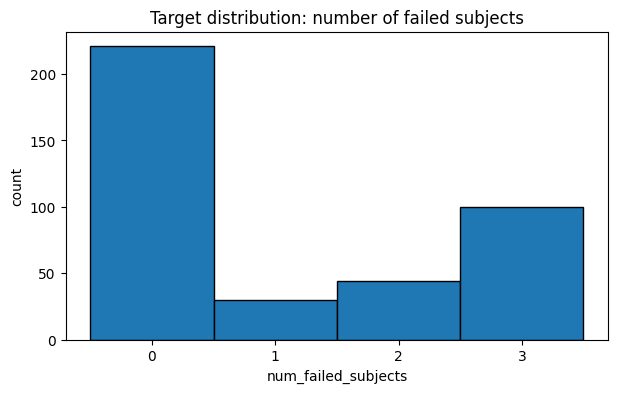

In [ ]:
# Visual check of target distribution
plt.figure(figsize=(7, 4))
plt.hist(df["num_failed_subjects"], bins=[-0.5, 0.5, 1.5, 2.5, 3.5], edgecolor="black")
plt.xticks([0, 1, 2, 3])
plt.title("Target distribution: number of failed subjects")
plt.xlabel("num_failed_subjects")
plt.ylabel("count")
plt.show()


### What to check after Step 4

Check:

1. Are the target values only 0, 1, 2, and 3?
2. Is the target imbalanced?
3. Are there very few cases for any target value?

Short answer format:

```text
The target ranges from ___ to ___. Most students have __ failed subjects. This matters because rare target values may be harder to predict.
```

**Dataset-Specific Answer**

The target variable num_failed_subjects ranges from 0 to 3.

Most students have 0 failed subjects (approximately 55.9% of the dataset), making it the most common target value.

The target distribution is somewhat imbalanced, as the values 1 and 2 occur less frequently (7.6% and 11.1% respectively) compared to 0 and 3.

This is important because rare target values may be harder for the model to predict accurately and could influence model evaluation results.

Overall, the target appears moderately imbalanced but still contains observations across all target values.
*********************************************************
**Universal Practical Test Template**

The target variable ranges from [MIN] to [MAX].

The most common target value is [VALUE], representing approximately [PERCENT]% of observations.

The distribution appears [balanced / moderately imbalanced / imbalanced], with some target values occurring less frequently than others.

This is important because rare target values may be more difficult for the model to learn and predict accurately.

Overall, the target distribution should be considered during model evaluation and interpretation.


*****************************************************
Decision: Accept

The target distribution appears reasonably balanced, and no significant imbalance concerns were identified. Therefore, no additional resampling or class-balancing techniques are required at this stage.

## Step 5. Define X and y, then remove leakage columns

This is a very important test point.

`G1`, `G2`, and `G3` are used to calculate `num_failed_subjects`.

If you include them as predictors, the model is indirectly given the answer.

That is leakage.

### Simple example

If I already know all three subject marks, I can calculate the number of failed subjects directly.

So the model does not need to learn from behaviour, background, or other features. It is just using the answer source.

<div style="background-color:#fff0f0; border-left:6px solid #d93636; padding:12px;">
<strong>Rule for this task:</strong> Drop <code>G1</code>, <code>G2</code>, and <code>G3</code> from X after creating the target.
</div>


In [ ]:
target_col = "num_failed_subjects"
leakage_cols = ["G1", "G2", "G3"]

X = df.drop(columns=[target_col] + leakage_cols)
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Columns removed for leakage:", leakage_cols)


X shape: (395, 30)
y shape: (395,)
Columns removed for leakage: ['G1', 'G2', 'G3']


### Decision point after Step 5

Write this in your answer if asked about leakage:

```text
I removed G1, G2 and G3 because the target is calculated from these columns. Keeping them would leak the answer into the model and make the evaluation unrealistic.
```
**Short Exam Version answer template**
I removed G1, G2, and G3 because the target (num_failed_subjects) was calculated from these grade columns. Keeping them as predictors would cause target leakage and artificially inflate model performance.

## Step 6. Train/test split

The test set is used only for final checking.

For normal regression, we usually do not stratify.

However, this target is a small integer count: 0, 1, 2, 3. It behaves partly like groups. In this revision example, we use `stratify=y` so the train and test sets keep similar target proportions.

### Caveat
If the target has rare values, stratified splitting may fail or create very small groups. Always check the value counts.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nTrain target proportions:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest target proportions:")
print(y_test.value_counts(normalize=True).sort_index())


Train shape: (355, 30) (355,)
Test shape: (40, 30) (40,)

Train target proportions:
num_failed_subjects
0    0.560563
1    0.076056
2    0.109859
3    0.253521
Name: proportion, dtype: float64

Test target proportions:
num_failed_subjects
0    0.550
1    0.075
2    0.125
3    0.250
Name: proportion, dtype: float64


Tum Note: I used train_test_split() to divide the dataset into training and testing sets. The training set is used to build the model, while the test set is reserved for final evaluation. A test size of 10% was used, random_state=42 ensures reproducibility, and stratify=y preserves the target distribution across both datasets.

### What to check after Step 6

Check that the train and test target proportions are reasonably similar.

Short answer format:

```text
The train and test sets have similar target proportions, so the holdout test set is a reasonable final check.
```
**Dataset-Specific Answer**

The dataset was split into 355 training observations (90%) and 40 testing observations (10%).

A stratified split was used to preserve the distribution of the target variable (num_failed_subjects) in both the training and testing datasets.

Comparing the target proportions shows that the distributions are very similar:

Target = 0: Train 56.1%, Test 55.0%
Target = 1: Train 7.6%, Test 7.5%
Target = 2: Train 11.0%, Test 12.5%
Target = 3: Train 25.4%, Test 25.0%

Since the target proportions are consistent across both datasets, the train/test split appears representative and suitable for model training and final evaluation.

**Short Exam Version**
The dataset was split into training (90%) and testing (10%) sets using stratification. The target proportions in both sets are very similar, indicating that the test set is representative of the overall dataset and suitable for final model evaluation.

## Step 7. Build the preprocessing pipeline

The dataset has both numeric and categorical columns.

A pipeline helps you apply the same preparation steps during training and prediction.

### What happens here

| Column type | What we do |
|---|---|
| Numeric columns | Pass through as they are |
| Categorical columns | One-hot encode them |

### Why this matters

A pipeline reduces mistakes because the preprocessing is fitted on the training data and then applied consistently to validation and test data.

This avoids common errors such as preparing train and test data differently.


In [ ]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

**Tum Note**: The preprocessing pipeline uses a ColumnTransformer to handle different data types appropriately. Numeric columns are passed through unchanged, while categorical columns are converted using One-Hot Encoding. This ensures that all features are in a format suitable for machine learning models and that preprocessing is applied consistently during training and prediction.

### What to check after Step 7

Check:

1. Did the code correctly separate numeric and categorical columns?
2. Are categorical columns being encoded?
3. Is the preprocessing inside the pipeline later?

Short answer format:

```text
The pipeline uses a ColumnTransformer so numeric and categorical columns are handled consistently before modelling.
```

**Recommended Answer**

The preprocessing pipeline correctly separates numeric and categorical columns. Numeric features are passed through unchanged, while categorical features are encoded using One-Hot Encoding. This preprocessing is stored inside a ColumnTransformer and will be applied consistently during model training and prediction.

**Universal Template**

The preprocessing pipeline correctly separates numeric and categorical variables. Numeric features are [passed through/scaled], while categorical features are encoded using [One-Hot Encoding/other encoding method]. This ensures consistent preprocessing before model training and evaluation.

**If Using standardScaler:**

The preprocessing pipeline correctly separates numeric and categorical columns. Numeric features are standardised using StandardScaler, while categorical features are encoded using One-Hot Encoding. This ensures that all features are prepared consistently before modelling.

# Just in case: Preprocessing: Write your own code

| Situation                  | What to Use                   |
| -------------------------- | ----------------------------- |
| No missing values          | Current template              |
| Missing numeric values     | SimpleImputer(median)         |
| Missing categorical values | SimpleImputer(most\_frequent) |
| Strongly skewed variable   | np.log1p()                    |
| Tree models only           | Scaling usually not required  |
| Linear/Logistic/KNN/SVM    | Consider StandardScaler       |


In [ ]:
# Don't execute !!!!!!! For practical test reference only
# Incase need to write new code during Preprocessing (ColumnTransformer)
# Scenario A: Scaling Required
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),  # Change to ("num", StandardScaler(), num_cols) => If need StandardScaler
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Scenario B: Missing Values Exist
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # 1.Replace missing value with median
    ("scaler", StandardScaler())    # 2. convert the variable into similar scales (Linear Regression, Logistic Regression but less important for DecisionTree, Randomforest, XGBoost)
])


In [ ]:
# Just incase. Don't execute: Complete code for Missing values + Scaling
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [ ]:
# Just in case
# Code to apply log transformation to highly scew dataset
df["column name_log"] = np.log1p(df["column name"])
df[["column name", "column name_log"]].head()

**Exam Explanation**

I applied a log transformation to absences using np.log1p() because the variable appears highly right-skewed, with a maximum value of 75 compared to a median of 4. The transformation reduces the influence of extreme values and may improve model performance.

# **Step 8. Train and compare models using CV**

We compare two tree-based models:

- Random Forest
- XGBoost

The main point is not to memorise the model code.

The main point is to compare fairly using the same:

1. train/test split,
2. preprocessing,
3. CV method,
4. metric.

### CV reminder

Cross-validation repeats model checking on different splits of the training data.

Here we use `ShuffleSplit`:

```text
Round 1: use part of training data for validation, train on the rest
Round 2: reshuffle, use another validation part, train on the rest
...
Average the validation scores
```

We also record train MAE so we can check overfitting.


**Practical Test Answer**

Cross-validation was used to evaluate model performance across multiple train-validation splits. This provides a more reliable estimate of generalisation performance than a single train-test split. Random Forest and XGBoost were compared using the same preprocessing, validation method and evaluation metric (MAE). Train MAE and validation MAE were also compared to assess potential overfitting.

In [ ]:
# Can ignore this

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Step 8A (Train/test spli, Preprocessing, CV method & Metric)
cv = ShuffleSplit(
    n_splits=5,
    test_size=0.20,
    random_state=42
)

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():

    pipe = Pipeline(
        [("preprocessor", preprocessor),
        ("regressor", model)]
    )

    cv_out = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    cv_mae = -cv_out["test_score"]

    results.append({
        "Model": name,
        "CV MAE Scores": np.round(cv_mae, 3),
        "Mean CV MAE": round(cv_mae.mean(), 3),
        "Std CV MAE": round(cv_mae.std(), 3)
    })

cv_results = (
    pd.DataFrame(results)
    .sort_values("Mean CV MAE")
)

display(cv_results)

,Model,CV MAE Scores,Mean CV MAE,Std CV MAE
1,XGBoost,"[1.086, 1.104, 1.044, 0.864, 0.95]",1.009,0.090
0,Random Forest,"[1.127, 1.124, 1.042, 0.925, 0.952]",1.034,0.084


We use three common regression metrics.

| Metric | Plain meaning | Better when |
|---|---|---|
| MAE | Average absolute error in dollars | Lower is better |
| RMSE | Error that punishes large mistakes more | Lower is better |
| R² | How much variation is explained | Higher is better |

For business explanation, MAE is often easiest because it is in the same unit as the target: Singapore dollars.

R2 => Expected to close to 1

| Metric            | Plain Meaning                                            | Better When                       |
| ----------------- | -------------------------------------------------------- | --------------------------------- |
| **CV MAE Scores** | MAE obtained from each Cross-Validation fold             | Scores should be consistently low |
| **Mean CV MAE**   | Average MAE across all CV folds (overall CV performance) | Lower is better                   |
| **Std CV MAE**    | Variation of CV MAE across folds (model stability)       | Lower is better                   |


**Observation**

XGBoost achieved the lowest Mean CV MAE (1.009), indicating slightly better average performance across the cross-validation folds.
Random Forest achieved a Mean CV MAE of 1.034, which is slightly worse than XGBoost.
The difference between the two models is small (0.025 MAE).
Random Forest has a slightly lower Std CV MAE (0.084) compared to XGBoost (0.090), suggesting slightly more stable performance across different validation splits.
**Conclusion**

XGBoost is the preferred model based on Cross Validation because it achieved the lowest Mean CV MAE (1.009). Although Random Forest was slightly more stable, the difference in stability is small and XGBoost showed better overall predictive performance.

**What's Next?**

Proceed to evaluate both models on the holdout test set using MAE, RMSE, and R². Then compare the holdout results with the CV results and check for potential overfitting by comparing training and validation performance.

Flow: Step 8A
Cross Validation Summary
↓
Mean CV MAE
↓
Choose leading model
↓
Step 8B
Full Model Evaluation
↓
Train MAE
↓
Validation MAE
↓
Train-Validation Gap
↓
Holdout MAE
↓
Holdout RMSE
↓
Holdout R²
↓
Final Model Selection


In [ ]:
# Step 8B (Modeling)
# Keep this small enough for a single revision session.
# The goal is model comparison, not exhaustive tuning.
# Model can be change to DecisionTreeRegressor(), RandomForestRegressor(), LinearRegression(), XGBRegressor()


cv = ShuffleSplit(n_splits=5, test_size=0.20, random_state=42)

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])

    cv_out = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",    # Scoring
        return_train_score=True,
        n_jobs=-1
    )

    train_mae = -cv_out["train_score"]
    val_mae = -cv_out["test_score"]

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    holdout_mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "model": name,
        "cv_train_mae_mean": train_mae.mean(),
        "cv_train_mae_std": train_mae.std(),
        "cv_val_mae_mean": val_mae.mean(),
        "cv_val_mae_std": val_mae.std(),
        "train_val_gap": val_mae.mean() - train_mae.mean(),
        "holdout_mae": holdout_mae,
        "holdout_rmse": rmse,
        "holdout_r2": r2
    })

    fitted_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("cv_val_mae_mean")
results_df


,model,cv_train_mae_mean,cv_train_mae_std,cv_val_mae_mean,cv_val_mae_std,train_val_gap,holdout_mae,holdout_rmse,holdout_r2
1,XGBoost,0.505079,0.017404,1.009434,0.090180,0.504355,1.066606,1.232403,0.090188
0,Random Forest,0.522767,0.026801,1.033943,0.083931,0.511176,0.954804,1.087251,0.291882


| Metric                    | Plain Meaning                                                           | Better When       |
| ------------------------- | ----------------------------------------------------------------------- | ----------------- |
| **CV Train MAE**          | Average error on training folds                                         | Lower is better   |
| **CV Train MAE Std**      | Variation of training error across folds                                | Lower is better   |
| **CV Validation MAE**     | Average error on validation folds (generalisation performance)          | Lower is better   |
| **CV Validation MAE Std** | Stability of validation performance across folds                        | Lower is better   |
| **Train-Validation Gap**  | Difference between Train MAE and Validation MAE (overfitting indicator) | Smaller is better |
| **Holdout MAE**           | Average prediction error on unseen test data                            | Lower is better   |
| **Holdout RMSE**          | Prediction error that penalises large mistakes more heavily             | Lower is better   |
| **Holdout R²**            | Percentage of target variation explained by the model                   | Higher is better  |

**Train-Validation Gap = CV Validation MAE Mean - CV Train MAE Mean **

| Observation                              | Interpretation      |
| ---------------------------------------- | ------------------- |
| Train MAE ≈ Validation MAE               | Good generalisation |
| Train MAE much lower than Validation MAE | Overfitting         |
| Train MAE and Validation MAE both high   | Underfitting        |
| Small Train-Validation Gap               | Better              |
| Large Train-Validation Gap               | Worse               |


| Train-Validation Gap                  | Interpretation           |
| ------------------------------------- | ------------------------ |
| < 0.10                                | Very good generalisation |
| 0.10 - 0.30                           | Mild overfitting         |
| 0.30 - 0.60                           | Moderate overfitting     |
| > 0.60                                | Significant overfitting  |
| Very small gap but both MAEs are high | Possible underfitting    |

eg. Train MAE = 0.30
Validation MAE = 1.20
Gap = 0.90    Interpretation:  Severe overfitting. The model performs extremely well on training data but poorly on unseen data.

Train MAE = 1.30
Validation MAE = 1.40
Gap = 0.10   Interpretation:

Underfitting. The model performs poorly on both training and validation data, suggesting it cannot learn the underlying patterns effectively.

**********************************************
**Exam Template (Overfitting & Underfitting)**
Good Generalisation

The Train-Validation Gap is small, suggesting the model generalises well to unseen data and does not exhibit significant overfitting.

Mild Overfitting

The Validation MAE is slightly higher than the Training MAE, indicating mild overfitting. However, the model still generalises reasonably well.

Moderate Overfitting

The Validation MAE is noticeably higher than the Training MAE, suggesting moderate overfitting. The model performs better on training data than on unseen data.

Severe Overfitting

The large Train-Validation Gap indicates severe overfitting. The model appears to memorise training patterns and does not generalise well to unseen data.

Underfitting

Both Training MAE and Validation MAE are relatively high with little difference between them, suggesting the model is unable to capture meaningful patterns in the data.

**Quick Interpretation Template**

The model achieved a CV Validation MAE of [x], indicating an average prediction error of approximately [x] units on unseen validation data. The Train-Validation Gap of [y] suggests [minimal/mild/moderate/severe] overfitting. On the holdout test set, the model achieved an MAE of [a], RMSE of [b], and R² of [c]. Overall, [Model Name[c] is selected because it provides the best balance of accuracy, generalisation, and stability.

**Reply Template (Data specific): Observation**

XGBoost achieved the lowest CV Validation MAE (1.009) compared to Random Forest (1.034), indicating slightly better average performance during cross-validation.

Random Forest achieved a slightly lower CV Validation MAE Standard Deviation (0.084) compared to XGBoost (0.090), suggesting marginally more stable performance across different validation splits.

Both models have a Train-Validation Gap of approximately 0.5, indicating mild to moderate overfitting because validation errors are noticeably higher than training errors.

**Holdout Test Evaluation**

On the unseen holdout test set, Random Forest achieved:

Lower MAE (0.955 vs 1.067)
Lower RMSE (1.087 vs 1.232)
Higher R² (0.292 vs 0.090)

compared to XGBoost.

This indicates that Random Forest generalised better to unseen data.

**Final Conclusion**

Although XGBoost achieved slightly better cross-validation performance, Random Forest performed better on the unseen holdout test set with lower prediction errors and a higher R² score.

Therefore, Random Forest is selected as the preferred model because final model selection should be based primarily on performance on unseen data.

*********************************************************************

**Universal Practical-Test Template**
Observation

[Model A] achieved the lowest CV Validation MAE ([value]), indicating the best average cross-validation performance.

[Model B] achieved the lowest CV Validation MAE Standard Deviation ([value]), indicating slightly more stable performance across folds.

The Train-Validation Gap ranges from [value] to [value], suggesting [minimal / mild / moderate / severe] overfitting.

**Holdout Test Evaluation**

On the unseen holdout test set, [Selected Model] achieved:

Lowest MAE ([value])
Lowest RMSE ([value])
Highest R² ([value])

indicating the strongest predictive performance.

**Final Conclusion**

Although [Model A] performed better during cross-validation, [Selected Model] achieved better holdout test results and is therefore selected as the final model.


*********************************************************
**Detailed Practical-Test Answer**    ******* use this *********

The model achieved a CV Train MAE of [train_mae] and a CV Validation MAE of [val_mae]. The Train-Validation Gap of [gap] indicates [low/moderate/high] overfitting. A smaller gap suggests that the model generalises well to unseen data, while a larger gap indicates that the model performs significantly better on training data than validation data. The CV Validation MAE Std of [val_std] indicates [stable/moderately stable/unstable] performance across different data splits.

On the hold[stable/moderately stable/out test set, the model achieved an MAE of [dout_rmse], and R² of [holdout_r2]. Compared with the other[ models, this model demonstrated [better/similar/weaker] predictive erformance on unseen data. Therefore, [Model Name] was selected as the final model because it achieved the best balance between validation performance, generalisation capability, and holdout test performance.

The Actual vs Predicted plot shows that many observations are relatively close to the diagonal reference line, indicating that the model is able to capture the general relationship between the features and the target variable. Although some prediction errors remain, the overall pattern suggests that the model has learned useful predictive information and demonstrates reasonable generalisation on unseen data.


### What to check after Step 8

Check the result table in this order:

1. Which model has lower **CV validation MAE**?
2. Is the train MAE much lower than the validation MAE?
3. Does the holdout MAE support the CV result?
4. Is the improvement meaningful, or only tiny?

Short answer format:

```text
I would choose ___ because it has lower validation MAE, the train-validation gap is acceptable, and the holdout MAE supports the CV result.
```

Do not choose a model only because it sounds more advanced.


# **Just In case: Model Type Changes**


Currently Template: RandomForestRegressor / XGBRegressor

What if Target is Categorical? => Need to change from RandomForestRegressor to RandomForestClassifier /  XGBRegressor to XGBClassifier

90% of the code stays the same. During the practical test, you'll usually only modify 3 areas:

1. Target variable
2. Preprocessing
3. Models

In [ ]:
# Scenario 2: Add Decision TreeRegressor into the current template

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
# Scenario 3: Linear Regression baseline
# Question: Compare a simple baseline model against tree models

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        random_state=42
    )
}

In [ ]:
# Scenario 4: Ridge Regression

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
models = {
    "Ridge": Ridge(alpha=1.0),

    "Random Forest": RandomForestRegressor(
        random_state=42
    )
}

In [ ]:
# Scenario 5: Classification Problem (Compare Tree-Based Classification models)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

y = df["pass_fail"]  # example of Target

0 = Fail
1 = Pass

models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42
    )
}

# scoring="neg_mean_absolute_error"   => Change to scoring="accuracy" or scoring="f1"
# holdout_mae, rmse & R2   => Change to below 4 items

#accuracy_score(y_test, y_pred)
#precision_score(y_test, y_pred)
#recall_score(y_test, y_pred)
#f1_score(y_test, y_pred)

| Model               | Type                        |
| ------------------- | --------------------------- |
| Logistic Regression | Linear Classification Model |
| Decision Tree       | Tree-Based Model            |
| Random Forest       | Ensemble Tree Model         |
| XGBoost             | Boosted Tree Model          |


In [ ]:
# Scenario 5.2 : Classification problm: Compare basedline model against advance models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    )
}

# **Classification Metrics Cheat Sheet**

| Metric                   | Plain Meaning                                                                     | Better When       |
| ------------------------ | --------------------------------------------------------------------------------- | ----------------- |
| **Accuracy**             | Percentage of predictions that are correct                                        | Higher is better  |
| **Precision**            | Of all predicted positives, how many were actually positive                       | Higher is better  |
| **Recall**               | Of all actual positives, how many were correctly identified                       | Higher is better  |
| **F1 Score**             | Balance between Precision and Recall                                              | Higher is better  |
| **ROC-AUC**              | Ability to distinguish between classes across all thresholds                      | Higher is better  |
| **PR-AUC**               | Precision-Recall performance, especially useful for imbalanced data               | Higher is better  |
| **CV Accuracy Mean**     | Average accuracy across CV folds                                                  | Higher is better  |
| **CV Accuracy Std**      | Stability of accuracy across CV folds                                             | Lower is better   |
| **Train-Validation Gap** | Difference between Train Accuracy and Validation Accuracy (overfitting indicator) | Smaller is better |

**Classification Metrics Formula Cheat Sheet**

Confusion Matrix Basics

Before the formulas:

|                        | Actual Positive     | Actual Negative     |
| ---------------------- | ------------------- | ------------------- |
| **Predicted Positive** | TP (True Positive)  | FP (False Positive) |
| **Predicted Negative** | FN (False Negative) | TN (True Negative)  |

Meaning
TP = Predicted Yes, Actually Yes
TN = Predicted No, Actually No
FP = Predicted Yes, Actually No
FN = Predicted No, Actually Yes

**Classification Metrics Summary Table**

| Metric          | Formula                                         | Plain Meaning                                            | Better When |
| --------------- | ----------------------------------------------- | -------------------------------------------------------- | ----------- |
| **Accuracy**    | (TP + TN) ÷ (TP + TN + FP + FN)                 | Overall correctness                                      | Higher      |
| **Precision**   | TP ÷ (TP + FP)                                  | Of predicted positives, how many are correct?            | Higher      |
| **Recall**      | TP ÷ (TP + FN)                                  | Of actual positives, how many did we find?               | Higher      |
| **F1 Score**    | 2 × (Precision × Recall) ÷ (Precision + Recall) | Balance between Precision and Recall                     | Higher      |
| **Specificity** | TN ÷ (TN + FP)                                  | Of actual negatives, how many did we identify correctly? | Higher      |
| **ROC-AUC**     | Area under ROC Curve                            | Ability to separate classes                              | Higher      |
| **PR-AUC**      | Area under Precision-Recall Curve               | Performance on imbalanced datasets                       | Higher      |

**Quick Interpretation Table**

| Metric    | Ask Yourself                                          |
| --------- | ----------------------------------------------------- |
| Accuracy  | How often is the model correct overall?               |
| Precision | When the model predicts "Yes", is it usually right?   |
| Recall    | Did the model find most of the real positives?        |
| F1 Score  | Is there a good balance between Precision and Recall? |
| ROC-AUC   | Can the model distinguish between classes well?       |
| PR-AUC    | Is the model good at finding rare positive cases?     |


In [ ]:
# Scenario 7 : Missing Values Exist

("num", "passthrough", num_cols)  # To remove and replace with =>

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))   # Inside the preprocessor. Model code remains unchanged.
])


# Or replace with
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Then
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [ ]:
# Scenario 8 : Need Scaling

("num", "passthrough", num_cols)  # To remove and replace by

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

## Step 9. Plot actual vs predicted values

This plot helps you see whether the model is roughly following the true target values.

Because the target is 0 to 3, predictions may be non-integers.

That is normal for regression.

Only round predictions if the question asks for integer outputs.


Best model based on CV validation MAE: XGBoost


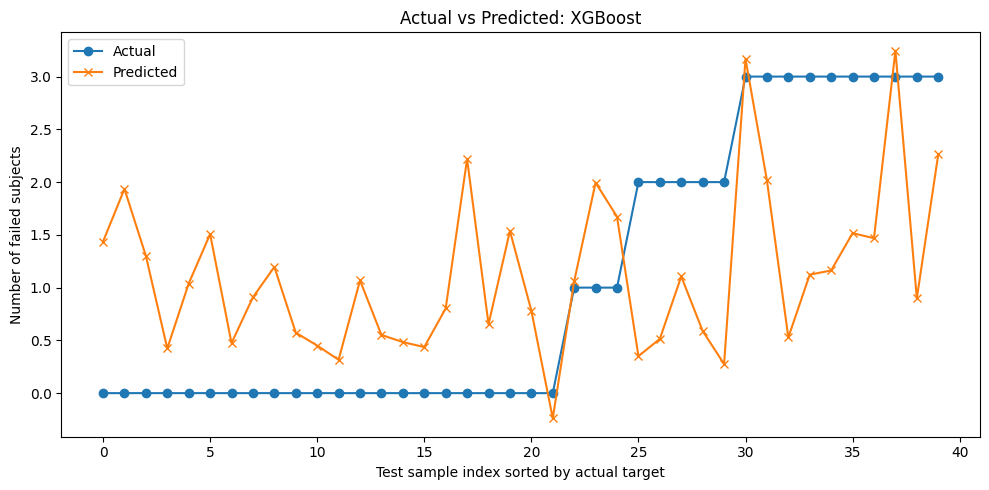

In [ ]:
# Choose the model with the best CV validation MAE
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]

print("Best model based on CV validation MAE:", best_model_name)

y_pred_test = best_model.predict(X_test)

# Sort by true target so the pattern is easier to see
order = np.argsort(y_test.to_numpy())
y_true_sorted = y_test.to_numpy()[order]
y_pred_sorted = y_pred_test[order]

plt.figure(figsize=(10, 5))
plt.plot(y_true_sorted, label="Actual", marker="o")
plt.plot(y_pred_sorted, label="Predicted", marker="x")
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.xlabel("Test sample index sorted by actual target")
plt.ylabel("Number of failed subjects")
plt.legend()
plt.tight_layout()
plt.show()


### What to check after Step 9

Look for:

1. Does the predicted line roughly follow the actual line?
2. Does the model over-predict students with 0 failed subjects?
3. Does the model under-predict students with 2 or 3 failed subjects?
4. Are the largest errors concentrated in rare target values?

Short answer format:

```text
The model generally follows the actual values, but it struggles more with ___ because ___.
```

**Practical-Test Answer (Dataset-Specific)**

The predicted values generally follow the overall pattern of the actual values, indicating that the model has learned meaningful relationships from the data.

However, the model tends to over-predict students with 0 failed subjects and shows some larger errors for individual observations. Predictions for students with 2 to 3 failed subjects appear closer to the actual values.

Overall, the model captures the general trend of the target variable, but prediction errors remain for some observations.

**Universal Template**

Use this for any dataset:

The predicted values generally follow the trend of the actual values, suggesting that the model has learned meaningful patterns from the data.

The model performs well for most observations but exhibits larger errors for certain cases. The largest prediction errors appear in [target group/value].

Overall, the model captures the general behaviour of the target variable, although there is still room for improvement through feature engineering or model tuning.


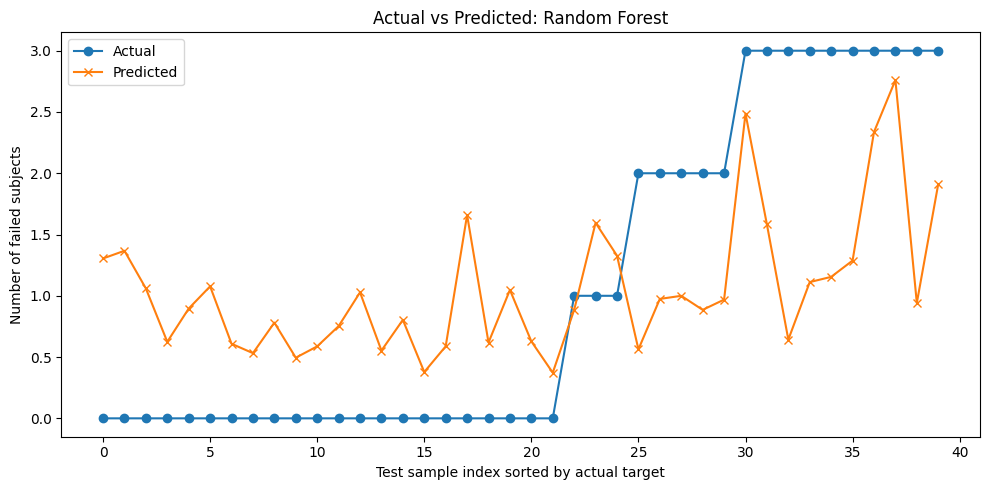

In [ ]:
# In case want to plot other model for visualization

model_name = "Random Forest"  # Just change the name here.
model = fitted_models[model_name]

y_pred_test = model.predict(X_test)

order = np.argsort(y_test.to_numpy())
y_true_sorted = y_test.to_numpy()[order]
y_pred_sorted = y_pred_test[order]

plt.figure(figsize=(10, 5))
plt.plot(y_true_sorted, label="Actual", marker="o")
plt.plot(y_pred_sorted, label="Predicted", marker="x")

plt.title(f"Actual vs Predicted: {model_name}")
plt.xlabel("Test sample index sorted by actual target")
plt.ylabel("Number of failed subjects")
plt.legend()
plt.tight_layout()
plt.show()

## Step 10. Final judgement answer

Use this structure for a short written response.

```text
I treated this as a regression task because the target is a numeric count: number of failed subjects.

I created the target by counting how many of G1, G2, and G3 are below 10.

I removed G1, G2, and G3 from the predictors because they directly define the target and would cause leakage.

I used a pipeline so that preprocessing and modelling are applied consistently.

Based on the CV validation MAE, train-validation gap, and holdout MAE, I would choose ___ because ___.
```

<div style="background-color:#eaf4ff; border-left:6px solid #2b7bbb; padding:12px;">
<strong>Recap:</strong> Good practical-test answers are short, evidence-based, and clear. You do not need to explain every line of code.
</div>


**Answer Templates**

treated this as a regression task because the target variable (num_failed_subjects) is a numeric count ranging from 0 to 3.

I created the target by counting how many of G1, G2, and G3 were below 10.

I removed G1, G2, and G3 from the predictors because they directly define the target variable and would cause target leakage.

I used a preprocessing pipeline to ensure that categorical encoding and model training were applied consistently across training and testing data.

Based on the cross-validation results, XGBoost achieved the lowest Mean CV MAE (1.009), indicating slightly better average validation performance. However, Random Forest achieved lower holdout MAE (0.955), lower RMSE (1.087), and higher R² (0.292) on the unseen test set.

Both models showed moderate overfitting because the Train-Validation Gap was approximately 0.5.

Therefore, I selected Random Forest as the final model because it demonstrated better performance on unseen data and achieved the strongest overall holdout evaluation results.


**Universal Practical-Test Template**

I treated this as a [regression/classification] task because [reason].

I created the target variable by [how the target was created].

I removed [columns] from the predictors because they [cause leakage / directly define the target / are identifiers].

I used a preprocessing pipeline to ensure that data transformations were applied consistently during model training and prediction.

Based on the cross-validation results, [Model A] achieved the best validation performance with a [metric] of [value].

However, [Model B] achieved the best holdout test performance with [metric values].

The Train-Validation Gap suggests [minimal/mild/moderate/severe] overfitting.

Therefore, I selected [Final Model] as the final model because it demonstrated the best performance on unseen data.


# Optional Reading

Read this only after the main route.

## Why this target is a slight edge case

The target `num_failed_subjects` has values like 0, 1, 2, and 3.

That can feel like classification because the values look like categories.

But in this notebook, we treat it as regression because the target is a count.

### Standard interpretation

| Situation | Usually use |
|---|---|
| Predict a continuous number, such as price | Regression |
| Predict a count, such as number of failed subjects | Often regression, sometimes count models |
| Predict a category, such as pass/fail | Classification |

### Edge case

If the task changes to “predict whether a student failed at least one subject”, then the target becomes:

```text
0 = no failed subject
1 = failed at least one subject
```

That becomes classification.

So the method depends on how the target is defined.


# Optional Reading: CV and train/test split

## Train/test split

A train/test split holds back some data for final checking.

The model should not use the test set during training or model selection.

## Cross-validation

CV checks the model several times using different validation splits inside the training data.

For ShuffleSplit, each round reshuffles the training data and creates a new validation split.

```text
Round 1: train on most of the training data, validate on a held-out part
Round 2: reshuffle, train again, validate on another held-out part
Round 3: reshuffle, train again, validate on another held-out part
```

This reduces the chance that your result is due to one lucky split.

## Stratification caveat

For normal regression, stratification is not usually used.

Here, the target is a small integer count. Using `stratify=y` helps keep the 0, 1, 2, 3 proportions similar between train and test.

If a target value is very rare, stratification may fail or give unstable results.


# Additional Practice

Do these after class or during revision.

## Practice 1: Explain leakage

Write a 3-line answer explaining why `G1`, `G2`, and `G3` should be removed.

## Practice 2: Improve one modelling choice

Try only one improvement:

- change Random Forest `max_depth`, or
- change XGBoost `max_depth`, or
- change XGBoost `learning_rate`.

Then compare the new result with the original result.

Do not tune many things at once.

## Practice 3: Ask the LLM to review your answer

Use this prompt:

```text
Here is my practical-test answer. Check if it is clear, evidence-based, and free from leakage mistakes. Do not rewrite everything. Point out only the top three improvements.
```

Paste your own answer below that prompt.


# **Tum Note: Open AI PRompt to generate python code**

In [ ]:
# Template: Universal Target Distribution Prompt

prompt = f"""
You are a senior data scientist.

TARGET INFORMATION

Target Column:
{target_col}

TARGET SUMMARY

{target_summary}

TASK

Review the target distribution.

INSTRUCTIONS

1. Describe the target distribution.
2. State the range of target values.
3. Identify the most common value.
4. Comment on balance or imbalance.
5. Explain potential modelling implications.
6. Recommend any special handling if necessary.
7. Recommend ONE simple chart to visualize the target distribution.
8. Generate executable matplotlib code for the chart.

OUTPUT FORMAT

Target Distribution Summary

Imbalance Assessment

Practical-Test Answer

Recommended Chart

Python Code
"""

**Count-Type Targets:**

{target summary}: target_summary = df[target_col].value_counts(normalize=True).sort_index()

eg. target_summary = (
    df["num_failed_subjects"]
    .value_counts(normalize=True)
    .sort_index()
)

**Continuous Targets (Regression)**

target_summary = df["total_score"].describe()

# **Tum! If panic, start here !!!!!**

In [ ]:
# Panic prompt 1
# Universal Target Creation Prompt

# When the practical test asks you to create a target and you're unsure of the code:
# business requirement Example: Create a binary target variable called pass_fail where G3 >= 10 is 1 and G3 < 10 is 0.

# business_requirement = """

#Create a target variable representing the number of subjects with grades below 10 using G1, G2 and G3.

# """


from openai import OpenAI

from google.colab import userdata

client = OpenAI(

api_key=userdata.get("OPENAI_API_KEY")

)


business_requirement = """

Create a target variable representing the count number of subjects with grades below 10 using G1, G2 and G3.

A subject is considered failed when grade < 10.

"""

prompt = f"""
You are a senior data scientist.

DATASET INFORMATION

{payload_text}

TASK

Generate Python code to create the target variable according to the business requirement below:

{business_requirement}

REQUIREMENTS

1. Create the target column.
2. Name the target appropriately.
3. Add sanity checks.
4. Display first 5 rows showing source columns and target column.
5. Provide summary statistics.
6. Identify any leakage columns.
7. Explain briefly why the target is regression or classification.

OUTPUT

Provide executable Python code only.
"""

response = client.responses.create(

model="gpt-5.4-nano",

input=prompt

)

print(response.output_text)

In [ ]:
# Prompt 2 : Review Target variable whether balance or not (Not python code execute)


from openai import OpenAI

from google.colab import userdata

client = OpenAI(

api_key=userdata.get("OPENAI_API_KEY")

)

target_col = "num_failed_grades_lt10"

prompt = f"""
You are a senior machine learning engineer reviewing a target variable before modelling.

DATASET INFORMATION

{payload_text}

TARGET

{target_col}

TASK

Review the target variable and assess whether target imbalance may affect modelling.

INSTRUCTIONS

1. Explain what the target variable represents.

2. Review the target distribution:

{df[target_col].value_counts().to_string()}

Target Percentage Distribution:

{(df[target_col].value_counts(normalize=True)*100).round(2).to_string()}

3. Determine whether the target is:

- Balanced
- Moderately Imbalanced
- Highly Imbalanced

4. Explain why.

5. Explain the potential impact on model performance.

6. For this target, recommend whether any action is required.

Possible actions:

- No action required
- Stratified sampling
- Class weighting
- Oversampling
- Undersampling
- SMOTE
- Monitor metrics only

7. Explain whether the target should be treated as:

- Regression
- Classification

8. Explain whether imbalance handling is necessary.

9. Provide a practical-test-ready summary.

OUTPUT FORMAT

Target Summary

Target Distribution Assessment

Balanced / Moderately Imbalanced / Highly Imbalanced

Impact on Modelling

Recommended Action

Problem Type

Practical-Test Answer
"""

response = client.responses.create(

model="gpt-5.4-nano",

input=prompt

)

print(response.output_text)

In [ ]:
# Panic prompt 3

# My "Emergency Practical Test Prompt"

# If you're under time pressure:


target_col = "num_failed_grades_lt10"

prompt = f"""
You are a senior machine learning engineer helping a student during a practical test.

DATASET INFORMATION

{payload_text}

TARGET INFORMATION

Target Column:
{target_col}

IMPORTANT

This is a REGRESSION problem.

The target was created by counting the number of failed subjects across G1, G2 and G3.

A subject is failed when grade < 10.

Possible target values may include 0, 1, 2, 3 and should be treated as a REGRESSION target.

Do NOT auto-detect whether the problem is regression or classification.

Remove G1, G2 and G3 from X because they were used to create the target and will cause target leakage.

MODELS TO USE

Use only:

- DecisionTreeRegressor
- RandomForestRegressor
- XGBRegressor

Do NOT use:

- LogisticRegression
- RandomForestClassifier
- XGBClassifier
- KNN
- SVM
- Neural Networks
- Task auto-detection

TASK

Generate SIMPLE Google Colab notebook code suitable for a practical test.

The code must:

1. Create X and y.
2. Remove leakage columns.
3. Split train and test data.
4. Automatically detect numerical and categorical columns.
5. Create preprocessing using:
   - StandardScaler for numerical columns
   - OneHotEncoder(handle_unknown='ignore') for categorical columns
6. Compare:
   - DecisionTreeRegressor
   - RandomForestRegressor
   - XGBRegressor
7. Use ShuffleSplit cross-validation:
   - n_splits=5
   - test_size=0.20
   - random_state=42
8. Use MAE as the primary cross-validation metric.
9. Create a comparison table for all models showing:
   - Model
   - CV Train MAE Mean
   - CV Train MAE Std
   - CV Validation MAE Mean
   - CV Validation MAE Std
   - Train Validation Gap
   - Holdout MAE
   - Holdout RMSE
   - Holdout R²

10. Evaluate the holdout test set using:
   - MAE
   - RMSE
   - R²
11. Store models in a dictionary called fitted_models.
12. Create an Actual vs Predicted plot.
13. Include all required imports.
14. Add simple comments.

CODE REQUIREMENTS

- Keep code under 150 lines.
- Use only pandas, numpy, sklearn and xgboost.
- Do not create custom functions.
- Do not create classes.
- Do not use __main__.
- Do not use advanced Python syntax.
- Do not generate production-style code.
- Write code exactly as a student would write in a Google Colab notebook.
- Code must run from top to bottom in a single notebook cell.

OUTPUT

Return executable Python code only.
Do not provide explanations.
Do not provide markdown.
Do not provide discussion.
"""

response = client.responses.create(

model="gpt-5.4-nano",

input=prompt

)

print(response.output_text)

In [ ]:
# Panic Prompt 4: Model Review & Final Recommendation


from openai import OpenAI
from google.colab import userdata

client = OpenAI(
    api_key=userdata.get("OPENAI_API_KEY")
)

target_col = 'num_failed_subjects'

prompt = f"""
You are a senior machine learning engineer reviewing a practical test submission.

DATASET INFORMATION

{payload_text}

TARGET

{target_col}

MODEL RESULTS

{comparison}

TASK

Review the modelling results and provide a practical-test-ready recommendation.

INSTRUCTIONS

1. Explain the performance metrics.
2. Compare all models.
3. Identify the best model.
4. Explain why it is the best model.
5. Assess whether any model appears overfitted.
6. Assess whether any model appears underfitted.
7. Comment on model stability if cross-validation results are available.
8. Provide a final recommendation.
9. State whether you:
   - Accept
   - Accept with Modification
   - Reject

10. Explain the decision in simple business language.

11. Generate a short practical-test answer (3-5 sentences).

12. Generate a detailed practical-test answer (1 paragraph).

13. Recommend one simple chart to include.

14. Generate executable matplotlib code for that chart.

OUTPUT FORMAT

Metric Interpretation

Model Comparison

Overfitting Assessment

Decision:
Accept / Accept with Modification / Reject

Reason

Best Model

Short Practical-Test Answer

Detailed Practical-Test Answer

Visualization Recommendation

Python Code
"""

response = client.responses.create(
    model="gpt-5.4-nano",
    input=prompt
)

print(response.output_text)

In [ ]:
# Universal Preprocessing Prompt

# Use when the dataset has missing values, outliers, scaling needs, or encoding concerns.

prompt = f"""
You are a senior machine learning engineer.

DATASET INFORMATION

{payload_text}

TASK

Recommend and generate Python preprocessing code.

REQUIREMENTS

1. Identify numerical columns.
2. Identify categorical columns.
3. Handle missing values appropriately.
4. Recommend whether scaling is needed.
5. Identify possible outlier treatments.
6. Identify potential log-transform candidates.
7. Build a complete ColumnTransformer pipeline.
8. Include comments explaining each step.

OUTPUT

Provide executable Python code only.
"""

In [ ]:
# Template 1: Universal Regression Modelling Prompt after new target column created (Target is numeric)  Read carefully as need to change the message

from openai import OpenAI

from google.colab import userdata

client = OpenAI(

api_key=userdata.get("OPENAI_API_KEY")

)

target_col = "num_failed_subjects"  # To change the target column name

prompt = f"""
You are a senior machine learning engineer.

I am working on a regression problem.

DATASET INFORMATION

{payload_text}

TARGET INFORMATION

Target Column:
{target_col}

The target column already exists in the dataframe.

Target Origin:
Created from G1, G2 and G3 by counting grades below 10.

TASK

Generate COMPLETE Python code that can be executed directly in Google Colab.

REQUIREMENTS

1. Create X and y.
2. Remove any leakage columns if they are used to create the target.
3. Split data into train and test sets.
4. Automatically detect numerical and categorical columns.
5. Build a preprocessing pipeline using:
   - StandardScaler for numerical columns
   - OneHotEncoder(handle_unknown="ignore") for categorical columns
6. Compare these models:
   - DecisionTreeRegressor
   - RandomForestRegressor
   - XGBRegressor
7. Use ShuffleSplit cross-validation:
   - n_splits=5
   - test_size=0.20
   - random_state=42
8. Use MAE as the main CV metric.
9. Produce a results table containing:
   - Model
   - CV MAE Scores
   - Mean CV MAE
   - Std CV MAE
10. Evaluate the models on the holdout test set using:
   - MAE
   - RMSE
   - R²
11. Store fitted models in a dictionary called fitted_models.
12. Select the best model.
13. Create an Actual vs Predicted plot.
14. Add comments explaining every major code section.
15. Ensure all required imports are included.

OUTPUT

Provide executable Python code only.
"""

response = client.responses.create(

model="gpt-5.4-nano",

input=prompt

)

print(response.output_text)

In [ ]:
# Template 2 : Universal Classification Modelling Prompt (Target is Pass/Fail, Yes/No, 0/1, Binary Classification, Multi-class Classification)

prompt = f"""
You are a senior machine learning engineer.

I am working on a classification problem.

DATASET INFORMATION

{payload_text}

TARGET INFORMATION

Target Column:
{target_col}

TASK

Generate COMPLETE Python code that can be executed directly in Google Colab.

REQUIREMENTS

1. Create X and y.
2. Remove any leakage columns if they are used to create the target.
3. Split data into train and test sets.
4. Use stratified train-test split.
5. Automatically identify:
   - numerical columns
   - categorical columns
6. Create preprocessing pipeline:
   - StandardScaler for numerical columns
   - OneHotEncoder(handle_unknown="ignore") for categorical columns
7. Compare these models:
   - LogisticRegression
   - RandomForestClassifier
   - XGBClassifier
8. Use ShuffleSplit cross-validation:
   - n_splits=5
   - test_size=0.20
   - random_state=42
9. Use F1 Score as the primary CV metric.
10. Produce a results table containing:
    - Model
    - CV F1 Scores
    - Mean CV F1
    - Std CV F1
11. Evaluate holdout test performance using:
    - Accuracy
    - Precision
    - Recall
    - F1 Score
12. Store fitted models in fitted_models.
13. Select the best model.
14. Generate:
    - Confusion Matrix
    - Classification Report
15. Add comments explaining every major code section.
16. Include all required imports.

OUTPUT

Provide executable Python code only.
"""

# **Model Review Prompt for ADALL practical tests**

pass your results_df (or CV results table) to the LLM and ask it to:

Review model performance

Identify the best model

Explain the metrics

Assess overfitting

Recommend the final model

Generate simple visualization code

**Prompt A: Regression Model Review**

In [ ]:
# Prompt A: Regression Model Review

prompt = f"""
You are a senior machine learning engineer.

MODEL RESULTS

{results_df}

TASK

Review the regression model results.

INSTRUCTIONS

1. Explain each metric:
   - CV Validation MAE
   - CV Validation MAE Std
   - Holdout MAE
   - Holdout RMSE
   - Holdout R²
   - Train-Validation Gap

2. Compare all models.

3. Identify:
   - Best cross-validation model
   - Most stable model
   - Least overfitted model
   - Best holdout model

4. Discuss whether any model appears:
   - Overfitted
   - Underfitted
   - Well-generalized

5. Recommend the final model.

6. Explain why that model should be selected.

7. Provide a concise practical-test answer.

8. Suggest ONE simple matplotlib chart to visualize model performance.

OUTPUT FORMAT

Metric Interpretation

Model Comparison

Overfitting Assessment

Recommended Model

Practical Test Answer

Matplotlib Code
"""

response = client.responses.create(

model="gpt-5.4-nano",

input=prompt

)



print(response.output_text)

**Prompt B: Classification Model Review**

In [ ]:
# Prompt B: Classification Model Review

prompt = f"""
You are a senior machine learning engineer.

MODEL RESULTS

{results_df}

TASK

Review the classification model results.

INSTRUCTIONS

1. Explain:
   - Accuracy
   - Precision
   - Recall
   - F1 Score

2. Compare all models.

3. Identify:
   - Best Accuracy
   - Best Precision
   - Best Recall
   - Best F1 Score

4. Recommend the final model.

5. Explain any trade-offs.

6. Provide a concise practical-test answer.

7. Suggest ONE simple visualization.

OUTPUT FORMAT

Metric Interpretation

Model Comparison

Recommended Model

Practical Test Answer

Matplotlib Code
"""

response = client.responses.create(

model="gpt-5.4-nano",

input=prompt

)



print(response.output_text)

**Prompt C: Request Chart Code Only**

In [ ]:
# Prompt C: Request Chart Code Only


prompt = f"""
You are a senior data scientist.

Regression model results:

{results_df}

Generate simple matplotlib code to visualize model comparison.

Requirements:

1. Use bar charts.
2. Compare:
   - Holdout MAE
   - Holdout RMSE
   - Holdout R²
3. Use clear labels.
4. Include title.
5. Executable Google Colab code only.

Return code only.
"""

response = client.responses.create(

model="gpt-5.4-nano",

input=prompt

)



print(response.output_text)

**Prompt D: Full Practical-Test Reviewer (Recommended)**

**Model Evaluation**

In [ ]:
# Prompt D: Full Practical-Test Reviewer (Recommended for Model Evaluation)

prompt = f"""
You are a senior machine learning engineer reviewing a practical test submission.

DATASET SUMMARY

{payload_text}

TARGET

{target_col}

MODEL RESULTS

{results_df}

TASK

Review the model evaluation results.

Please provide:

1. Summary of model performance.
2. Interpretation of all metrics.
3. Which model performs best in cross-validation.
4. Which model performs best on holdout data.
5. Whether any model shows signs of overfitting.
6. Final model recommendation.
7. Practical-test-ready explanation (5-8 sentences).
8. One simple chart recommendation.
9. Python matplotlib code for the chart.

Keep explanations concise and suitable for a practical assessment.
"""

response = client.responses.create(

model="gpt-5.4-nano",

input=prompt

)



print(response.output_text)